In [2]:
import numpy as np
import pandas as pd

import torch
import torch.nn as nn

from torch.optim import SGD
from torch.utils.data import DataLoader

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

from matplotlib import pyplot as plt

import warnings 

warnings.filterwarnings('ignore')

## Överblick

**Nu ska vi träna Neurala Nätverk och få lite praktisk erfarenhet av Hyperparameters**

Vi kommer bygga och träna Neurala Nätverk för att lösa regressionsproblem.

**GRAFIKKORTSACCELERATION**

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Available device: {device}")

Available device: cpu


**DATA**

Ladda in data & delta upp i train- och testsplit

In [3]:
iris = load_iris()
  
x_train, x_test, y_train, y_test = train_test_split(iris.data,
                                                    iris.target,
                                                    test_size=0.1)

**Uppgift 1)**

Utforska & säkerställ att du förstår datan. Du kan läsa mer här:

https://archive.ics.uci.edu/dataset/53/iris

**Omvandla dataformat till tensorer**

In [4]:
# OBS, lägg märkte till att targets omvandlas till Long-format. Detta krävs för att vår loss-funktion korrekt ska mappa output y_pred till vår y_true nedan

x_train = torch.from_numpy(x_train).type(torch.FloatTensor)
y_train = torch.from_numpy(y_train).type(torch.LongTensor) 

x_test = torch.from_numpy(x_test).type(torch.FloatTensor)
y_test = torch.from_numpy(y_test).type(torch.LongTensor)

**Normalisara datan**

In [5]:

# OBS, lägg märkte till att statistiken räknas ut endast på train-split, och appliceras sedan på både train- och test.

# medelvärde
mean = x_train.mean(dim=0)

# standardavvikelse
std = x_train.std(dim=0)

x_train = (x_train - mean) / std
x_test = (x_test - mean) / std

**Lägg in GPU-support (om tillgänglig) samt paketera training- och testdatan**

In [6]:
x_train = x_train.to(device)
y_train = y_train.to(device)

x_test = x_test.to(device)
y_test = y_test.to(device)

training_set = list(zip(x_train, y_train))             
test_set = list(zip(x_test, y_test))                  

**Uppgift 2)**

Skapa ett klass NeuralNetwork, som du ska använda för multi-class classificering.

Klassen ska ta två argument, input_dim & output_dim.

Tips: datan är inte så komplicerad, så börja med ett nätverk med relativt liten kapacitet.

Tips: kolla föreläsningsvideon för att se hur man applicerar softmax

In [ ]:
class NeuralNetwork(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(NeuralNetwork, self).__init__()
        
        # TODO: definiera lager att initiera
        
    def forward(self, x):
        
        # TODO: Definiera forward()-metoden

        return x

In [7]:
input_size = 4   # spelar ej roll, beror på hur många features                   
output_size = 3  # avgör antalet klasser

class NeuralNetwork(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(NeuralNetwork, self).__init__()
        self.layer1 = nn.Linear(input_dim, 4)
        self.layer2 = nn.Linear(4, 4)
        self.layer3 = nn.Linear(4, output_dim)
        self.relu = nn.ReLU()
        self.softmax = nn.Softmax(dim=1)
        
    def forward(self, x):
        x = self.relu(self.layer1(x))
        x = self.relu(self.layer2(x))
        x = self.softmax(self.layer3(x))
        return x
    
model = NeuralNetwork(input_size, output_size)

**Uppgift 3)**

Ange lämplig värden för

input_size & output_size

In [ ]:
input_size = 4
output_size = 3

**Uppgift 4)**

Träna nu din modell för på epochs & learning rate. 

Vad verkar funka bra?

Hur ser loss-kurvorna ut? Hur tolkar du dem?

**Notera att vi lagt till ytterligare en plot under plotten för loss-kurvorna. Vad signifierar den?**

In [8]:
batch_size = 16

epochs = 500
learning_rate = 0.05

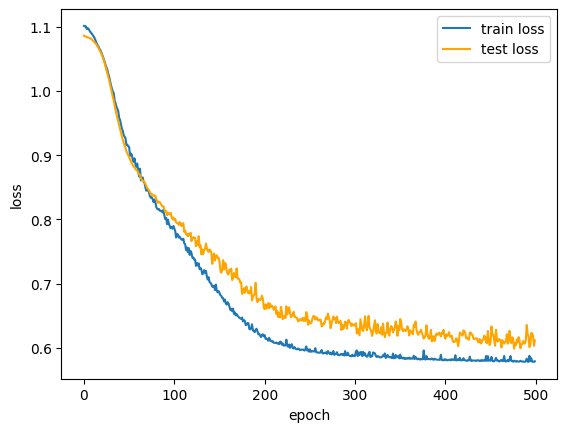

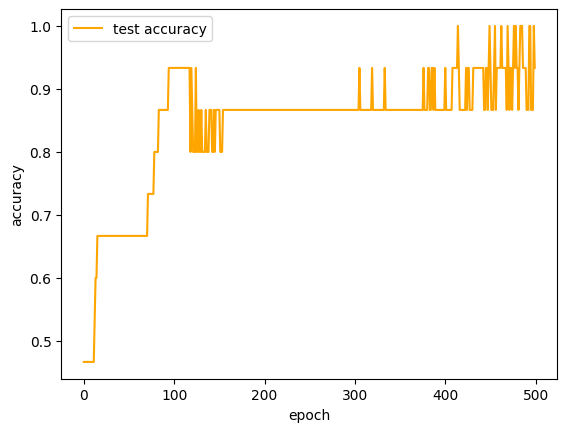

In [9]:
# ----------------------------------------------------------------------------------------------------------------
#    initera modell, loss_function, optimizer & dataloader


model = NeuralNetwork(input_size, output_size)
model = model.to(device)                                  # förbered modellen för GPU (om tillgänglig)


optimizer = SGD(model.parameters(), lr = learning_rate)
loss_function = torch.nn.CrossEntropyLoss()               # OBS, CrossEntropyLoss!

train_dataloader = DataLoader(training_set,                 
                              batch_size = batch_size,       
                              shuffle=True)


# ----------------------------------------------------------------------------------------------------------------
#    träna



batch_train_losses = []

epoch_train_losses = []
epoch_evaluation_losses = []
epoch_evaluation_accuracies = []

for epoch in range(epochs):
    
    model.train()

    running_loss = 0
    
    for batch in train_dataloader:
        
        y_true = batch[1]
        input_features = batch[0]
        
        y_pred=model(input_features)
        loss=loss_function(y_pred, y_true)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        
        batch_loss = loss.item()
        batch_train_losses.append(batch_loss)
    
    epoch_average_loss = np.average(batch_train_losses[-len(train_dataloader):])
    epoch_train_losses.append(epoch_average_loss)

# ----------------------------------------------------------------------------------------------------------------
#   evalueringssektion 

    #model.eval()
    
    y_true = y_test
    input_features = x_test
    
    y_pred = model(input_features)
    loss = loss_function(y_pred, y_true)
    
    evaluation_loss = loss.item()
    epoch_evaluation_losses.append(evaluation_loss)

# ----------------------------------------------------------------------------------------------------------------
#   evalueringssektion del 2 - samla in accuracy på test set


    _, predicted_class = torch.max(y_pred, dim=1)
    accuracy = (predicted_class == y_true).float().mean().item()
    epoch_evaluation_accuracies.append(accuracy)

# ----------------------------------------------------------------------------------------------------------------
#   plotta resultat 

plt.plot(epoch_train_losses, label = 'train loss')
plt.plot(epoch_evaluation_losses, label = 'test loss', color='orange')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()

plt.show()

plt.plot(epoch_evaluation_accuracies, label = 'test accuracy', color='orange')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.legend()

plt.show()

**Uppgift 5)**

Försök få så bra prestanda som möjligt genom att ändra nätverkets kapacitet. Börja med att justera antal lager och antal neuroner i varje lager.

### 1. Samma antal lager, dubbelt så många neuroner.

In [10]:
input_size = 4   # spelar ej roll, beror på hur många features                   
output_size = 3  # avgör antalet klasser

class NeuralNetwork(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(NeuralNetwork, self).__init__()
        self.layer1 = nn.Linear(input_dim, 8)
        self.layer2 = nn.Linear(8, 8)
        self.layer3 = nn.Linear(8, output_dim)
        self.relu = nn.ReLU()
        self.softmax = nn.Softmax(dim=1)
        
    def forward(self, x):
        x = self.relu(self.layer1(x))
        x = self.relu(self.layer2(x))
        x = self.softmax(self.layer3(x))
        return x
    
model = NeuralNetwork(input_size, output_size)

batch_size = 16

epochs = 500
learning_rate = 0.05

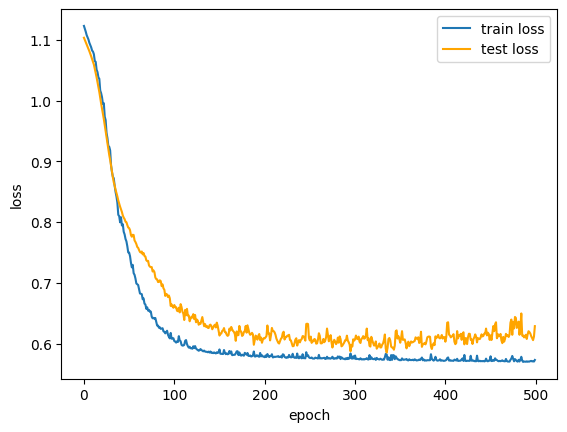

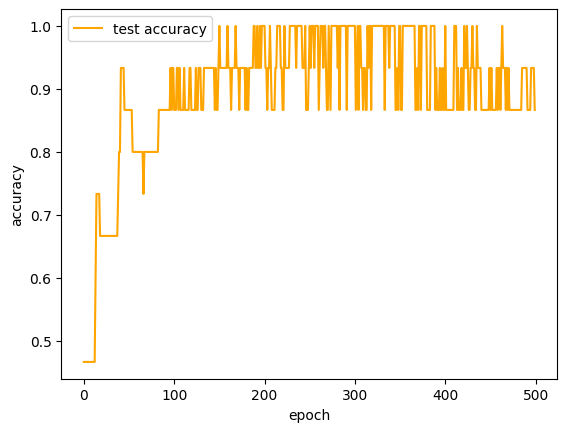

In [11]:
# ----------------------------------------------------------------------------------------------------------------
#    initera modell, loss_function, optimizer & dataloader


model = NeuralNetwork(input_size, output_size)
model = model.to(device)                                  # förbered modellen för GPU (om tillgänglig)


optimizer = SGD(model.parameters(), lr = learning_rate)
loss_function = torch.nn.CrossEntropyLoss()               # OBS, CrossEntropyLoss!

train_dataloader = DataLoader(training_set,                 
                              batch_size = batch_size,       
                              shuffle=True)


# ----------------------------------------------------------------------------------------------------------------
#    träna



batch_train_losses = []

epoch_train_losses = []
epoch_evaluation_losses = []
epoch_evaluation_accuracies = []

for epoch in range(epochs):
    
    model.train()

    running_loss = 0
    
    for batch in train_dataloader:
        
        y_true = batch[1]
        input_features = batch[0]
        
        y_pred=model(input_features)
        loss=loss_function(y_pred, y_true)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        
        batch_loss = loss.item()
        batch_train_losses.append(batch_loss)
    
    epoch_average_loss = np.average(batch_train_losses[-len(train_dataloader):])
    epoch_train_losses.append(epoch_average_loss)

# ----------------------------------------------------------------------------------------------------------------
#   evalueringssektion 

    #model.eval()
    
    y_true = y_test
    input_features = x_test
    
    y_pred = model(input_features)
    loss = loss_function(y_pred, y_true)
    
    evaluation_loss = loss.item()
    epoch_evaluation_losses.append(evaluation_loss)

# ----------------------------------------------------------------------------------------------------------------
#   evalueringssektion del 2 - samla in accuracy på test set


    _, predicted_class = torch.max(y_pred, dim=1)
    accuracy = (predicted_class == y_true).float().mean().item()
    epoch_evaluation_accuracies.append(accuracy)

# ----------------------------------------------------------------------------------------------------------------
#   plotta resultat 

plt.plot(epoch_train_losses, label = 'train loss')
plt.plot(epoch_evaluation_losses, label = 'test loss', color='orange')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()

plt.show()

plt.plot(epoch_evaluation_accuracies, label = 'test accuracy', color='orange')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.legend()

plt.show()

### 2. Samma antal neuroner, ett extra lager

In [12]:
input_size = 4   # spelar ej roll, beror på hur många features                   
output_size = 3  # avgör antalet klasser

class NeuralNetwork(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(NeuralNetwork, self).__init__()
        self.layer1 = nn.Linear(input_dim, 4)
        self.layer2 = nn.Linear(4, 4)
        self.layer3 = nn.Linear(4, 4)
        self.layer4 = nn.Linear(4, output_dim)
        self.relu = nn.ReLU()
        self.softmax = nn.Softmax(dim=1)
        
    def forward(self, x):
        x = self.relu(self.layer1(x))
        x = self.relu(self.layer2(x))
        x = self.relu(self.layer3(x))
        x = self.softmax(self.layer4(x))
        return x
    
model = NeuralNetwork(input_size, output_size)

batch_size = 16

epochs = 500
learning_rate = 0.05

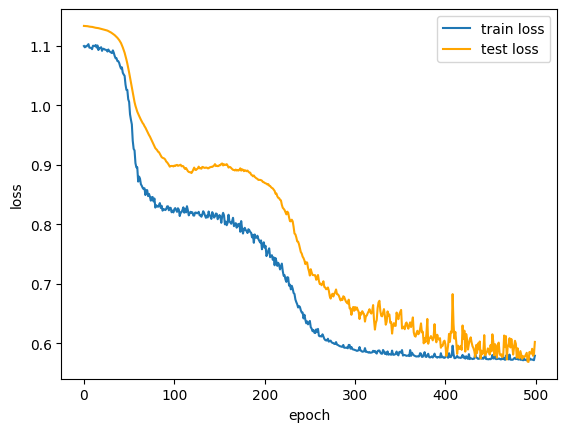

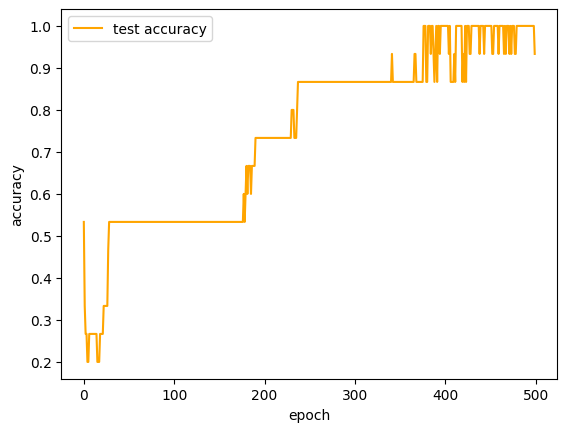

In [13]:
# ----------------------------------------------------------------------------------------------------------------
#    initera modell, loss_function, optimizer & dataloader


model = NeuralNetwork(input_size, output_size)
model = model.to(device)                                  # förbered modellen för GPU (om tillgänglig)


optimizer = SGD(model.parameters(), lr = learning_rate)
loss_function = torch.nn.CrossEntropyLoss()               # OBS, CrossEntropyLoss!

train_dataloader = DataLoader(training_set,                 
                              batch_size = batch_size,       
                              shuffle=True)


# ----------------------------------------------------------------------------------------------------------------
#    träna



batch_train_losses = []

epoch_train_losses = []
epoch_evaluation_losses = []
epoch_evaluation_accuracies = []

for epoch in range(epochs):
    
    model.train()

    running_loss = 0
    
    for batch in train_dataloader:
        
        y_true = batch[1]
        input_features = batch[0]
        
        y_pred=model(input_features)
        loss=loss_function(y_pred, y_true)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        
        batch_loss = loss.item()
        batch_train_losses.append(batch_loss)
    
    epoch_average_loss = np.average(batch_train_losses[-len(train_dataloader):])
    epoch_train_losses.append(epoch_average_loss)

# ----------------------------------------------------------------------------------------------------------------
#   evalueringssektion 

    #model.eval()
    
    y_true = y_test
    input_features = x_test
    
    y_pred = model(input_features)
    loss = loss_function(y_pred, y_true)
    
    evaluation_loss = loss.item()
    epoch_evaluation_losses.append(evaluation_loss)

# ----------------------------------------------------------------------------------------------------------------
#   evalueringssektion del 2 - samla in accuracy på test set


    _, predicted_class = torch.max(y_pred, dim=1)
    accuracy = (predicted_class == y_true).float().mean().item()
    epoch_evaluation_accuracies.append(accuracy)

# ----------------------------------------------------------------------------------------------------------------
#   plotta resultat 

plt.plot(epoch_train_losses, label = 'train loss')
plt.plot(epoch_evaluation_losses, label = 'test loss', color='orange')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()

plt.show()

plt.plot(epoch_evaluation_accuracies, label = 'test accuracy', color='orange')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.legend()

plt.show()

### 3. Ett extra lager OCH dubbelt så många neuroner

In [14]:
input_size = 4   # spelar ej roll, beror på hur många features                   
output_size = 3  # avgör antalet klasser

class NeuralNetwork(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(NeuralNetwork, self).__init__()
        self.layer1 = nn.Linear(input_dim, 8)
        self.layer2 = nn.Linear(8, 8)
        self.layer3 = nn.Linear(8, 8)
        self.layer4 = nn.Linear(8, output_dim)
        self.relu = nn.ReLU()
        self.softmax = nn.Softmax(dim=1)
        
    def forward(self, x):
        x = self.relu(self.layer1(x))
        x = self.relu(self.layer2(x))
        x = self.relu(self.layer3(x))
        x = self.softmax(self.layer4(x))
        return x
    
model = NeuralNetwork(input_size, output_size)

batch_size = 16

epochs = 500
learning_rate = 0.05

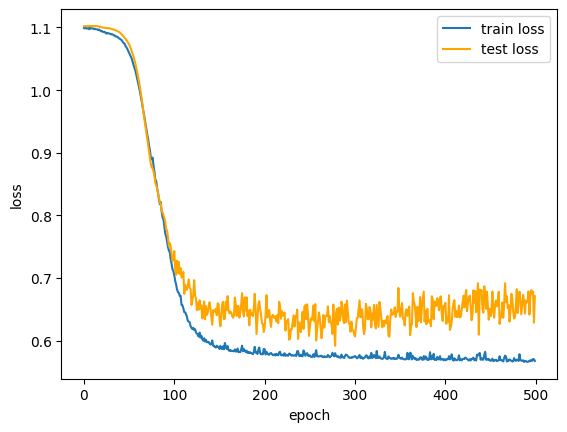

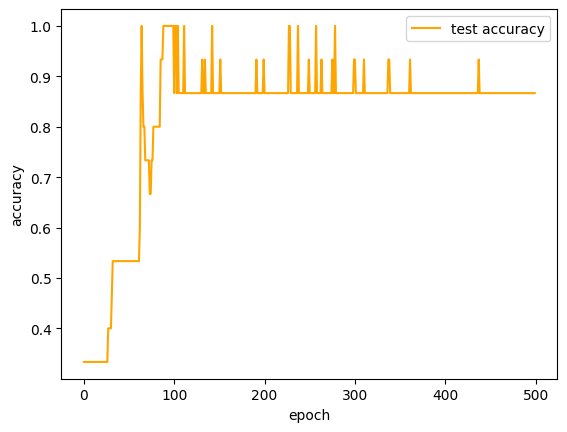

In [15]:
# ----------------------------------------------------------------------------------------------------------------
#    initera modell, loss_function, optimizer & dataloader


model = NeuralNetwork(input_size, output_size)
model = model.to(device)                                  # förbered modellen för GPU (om tillgänglig)


optimizer = SGD(model.parameters(), lr = learning_rate)
loss_function = torch.nn.CrossEntropyLoss()               # OBS, CrossEntropyLoss!

train_dataloader = DataLoader(training_set,                 
                              batch_size = batch_size,       
                              shuffle=True)


# ----------------------------------------------------------------------------------------------------------------
#    träna



batch_train_losses = []

epoch_train_losses = []
epoch_evaluation_losses = []
epoch_evaluation_accuracies = []

for epoch in range(epochs):
    
    model.train()

    running_loss = 0
    
    for batch in train_dataloader:
        
        y_true = batch[1]
        input_features = batch[0]
        
        y_pred=model(input_features)
        loss=loss_function(y_pred, y_true)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        
        batch_loss = loss.item()
        batch_train_losses.append(batch_loss)
    
    epoch_average_loss = np.average(batch_train_losses[-len(train_dataloader):])
    epoch_train_losses.append(epoch_average_loss)

# ----------------------------------------------------------------------------------------------------------------
#   evalueringssektion 

    #model.eval()
    
    y_true = y_test
    input_features = x_test
    
    y_pred = model(input_features)
    loss = loss_function(y_pred, y_true)
    
    evaluation_loss = loss.item()
    epoch_evaluation_losses.append(evaluation_loss)

# ----------------------------------------------------------------------------------------------------------------
#   evalueringssektion del 2 - samla in accuracy på test set


    _, predicted_class = torch.max(y_pred, dim=1)
    accuracy = (predicted_class == y_true).float().mean().item()
    epoch_evaluation_accuracies.append(accuracy)

# ----------------------------------------------------------------------------------------------------------------
#   plotta resultat 

plt.plot(epoch_train_losses, label = 'train loss')
plt.plot(epoch_evaluation_losses, label = 'test loss', color='orange')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()

plt.show()

plt.plot(epoch_evaluation_accuracies, label = 'test accuracy', color='orange')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.legend()

plt.show()

**Uppgift 6)**

Testa med att lägga till Dropout! Experimentera med vilka lager du påverkar, och med dropout rate

In [29]:
input_size = 4   # spelar ej roll, beror på hur många features                   
output_size = 3  # avgör antalet klasser

class NeuralNetwork(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(NeuralNetwork, self).__init__()
        self.layer1 = nn.Linear(input_dim, 8)
        self.layer2 = nn.Linear(8, 8)
        self.layer3 = nn.Linear(8, 8)
        self.layer4 = nn.Linear(8, output_dim)
        self.relu = nn.ReLU()
        self.softmax = nn.Softmax(dim=1)
        self.dropout1 = nn.Dropout(.2)
        self.dropout2 = nn.Dropout(.3)
        
    def forward(self, x):
        x = self.relu(self.layer1(x))
        
        x = self.relu(self.layer2(x))
        x = self.dropout1(x)
        x = self.relu(self.layer3(x))
        x = self.dropout2(x)
        x = self.softmax(self.layer4(x))
        return x
    
model = NeuralNetwork(input_size, output_size)

batch_size = 16

epochs = 500
learning_rate = 0.05

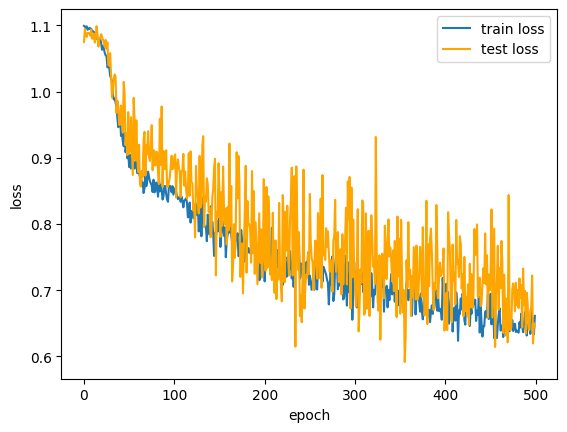

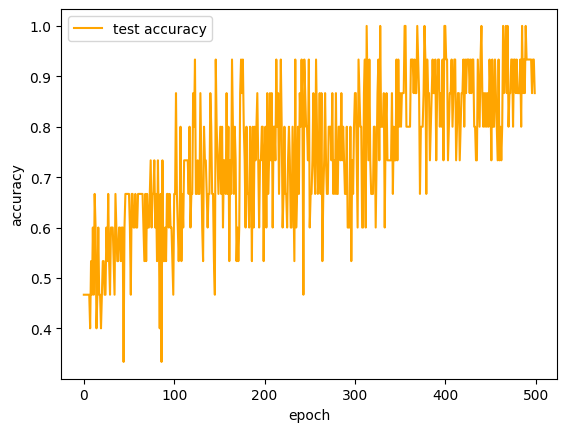

In [30]:
# ----------------------------------------------------------------------------------------------------------------
#    initera modell, loss_function, optimizer & dataloader


model = NeuralNetwork(input_size, output_size)
model = model.to(device)                                  # förbered modellen för GPU (om tillgänglig)


optimizer = SGD(model.parameters(), lr = learning_rate)
loss_function = torch.nn.CrossEntropyLoss()               # OBS, CrossEntropyLoss!

train_dataloader = DataLoader(training_set,                 
                              batch_size = batch_size,       
                              shuffle=True)


# ----------------------------------------------------------------------------------------------------------------
#    träna



batch_train_losses = []

epoch_train_losses = []
epoch_evaluation_losses = []
epoch_evaluation_accuracies = []

for epoch in range(epochs):
    
    model.train()

    running_loss = 0
    
    for batch in train_dataloader:
        
        y_true = batch[1]
        input_features = batch[0]
        
        y_pred=model(input_features)
        loss=loss_function(y_pred, y_true)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        
        batch_loss = loss.item()
        batch_train_losses.append(batch_loss)
    
    epoch_average_loss = np.average(batch_train_losses[-len(train_dataloader):])
    epoch_train_losses.append(epoch_average_loss)

# ----------------------------------------------------------------------------------------------------------------
#   evalueringssektion 

    #model.eval()
    
    y_true = y_test
    input_features = x_test
    
    y_pred = model(input_features)
    loss = loss_function(y_pred, y_true)
    
    evaluation_loss = loss.item()
    epoch_evaluation_losses.append(evaluation_loss)

# ----------------------------------------------------------------------------------------------------------------
#   evalueringssektion del 2 - samla in accuracy på test set


    _, predicted_class = torch.max(y_pred, dim=1)
    accuracy = (predicted_class == y_true).float().mean().item()
    epoch_evaluation_accuracies.append(accuracy)

# ----------------------------------------------------------------------------------------------------------------
#   plotta resultat 

plt.plot(epoch_train_losses, label = 'train loss')
plt.plot(epoch_evaluation_losses, label = 'test loss', color='orange')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()

plt.show()

plt.plot(epoch_evaluation_accuracies, label = 'test accuracy', color='orange')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.legend()

plt.show()

**Uppgift 7)**

Kan du även implementera regulariseringsmetoderna L1 & L2? Testa med olika styrkor. Börja med att köra utan dropout, lägg sedan till även dropout. Ser du någon skillnad?

In [31]:
input_size = 4   # spelar ej roll, beror på hur många features                   
output_size = 3  # avgör antalet klasser

class NeuralNetwork(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(NeuralNetwork, self).__init__()
        self.layer1 = nn.Linear(input_dim, 8)
        self.layer2 = nn.Linear(8, 8)
        self.layer3 = nn.Linear(8, 8)
        self.layer4 = nn.Linear(8, output_dim)
        self.relu = nn.ReLU()
        self.softmax = nn.Softmax(dim=1)
        
    def forward(self, x):
        x = self.relu(self.layer1(x))
        x = self.relu(self.layer2(x))
        x = self.relu(self.layer3(x))
        x = self.softmax(self.layer4(x))
        return x
    
model = NeuralNetwork(input_size, output_size)

batch_size = 16

epochs = 500
learning_rate = 0.05

In [32]:
# Define the training function with regularization
def train_model(model, criterion, optimizer, train_loader, regularization_type=None, lambda_reg=0.01, epochs=20):
    epoch_losses = []
    
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        
        for inputs, targets in train_loader:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs.squeeze(), targets)
            
            # Apply L1 regularization
            if regularization_type == 'L1':
                l1_norm = sum(p.abs().sum() for p in model.parameters())
                loss += lambda_reg * l1_norm
            
            # Apply L2 regularization
            elif regularization_type == 'L2':
                l2_norm = sum(p.pow(2).sum() for p in model.parameters())
                loss += lambda_reg * l2_norm
            
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * inputs.size(0)
        
        epoch_loss = running_loss / len(train_loader.dataset)
        epoch_losses.append(epoch_loss)
        print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss:.4f}")
    
    return epoch_losses

In [33]:
# Define the evaluation function
def evaluate_model(model, test_loader):
    model.eval()
    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, targets in test_loader:
            outputs = model(inputs)
            predicted = (outputs.squeeze() > 0.5).float()
            total += targets.size(0)
            correct += (predicted == targets).sum().item()
    
    accuracy = correct / total
    print(f"Accuracy: {accuracy:.4f}")
    return accuracy

In [37]:
# Plot loss over epochs
def plot_training_loss(losses, title):
    plt.plot(epoch_train_losses, label = 'train loss')
    plt.plot(epoch_evaluation_losses, label = 'test loss', color='orange')
    plt.xlabel('epoch')
    plt.ylabel('loss')
    plt.legend()


Training with L1 Regularization:
Epoch 1/20, Loss: 1.5109
Epoch 2/20, Loss: 1.4990
Epoch 3/20, Loss: 1.4881
Epoch 4/20, Loss: 1.4778
Epoch 5/20, Loss: 1.4678
Epoch 6/20, Loss: 1.4584
Epoch 7/20, Loss: 1.4489
Epoch 8/20, Loss: 1.4398
Epoch 9/20, Loss: 1.4307
Epoch 10/20, Loss: 1.4218
Epoch 11/20, Loss: 1.4133
Epoch 12/20, Loss: 1.4049
Epoch 13/20, Loss: 1.3968
Epoch 14/20, Loss: 1.3890
Epoch 15/20, Loss: 1.3811
Epoch 16/20, Loss: 1.3735
Epoch 17/20, Loss: 1.3660
Epoch 18/20, Loss: 1.3586
Epoch 19/20, Loss: 1.3513
Epoch 20/20, Loss: 1.3442


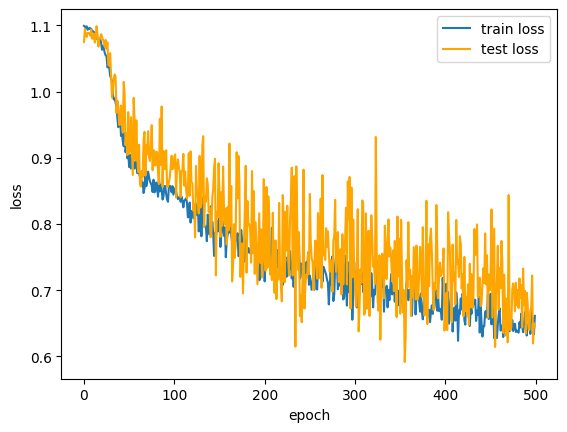

In [38]:
# Training and evaluating with L1 regularization
print("Training with L1 Regularization:")
model = NeuralNetwork(input_size, output_size)
model = model.to(device)                                  # förbered modellen för GPU (om tillgänglig)


optimizer = SGD(model.parameters(), lr = learning_rate)
criterion = torch.nn.CrossEntropyLoss()               # OBS, CrossEntropyLoss!

train_dataloader = DataLoader(training_set,                 
                              batch_size = batch_size,       
                              shuffle=True)


l1_losses = train_model(model, criterion, optimizer, train_dataloader, regularization_type='L1', lambda_reg=0.01)
#evaluate_model(model, test_loader)
plot_training_loss(l1_losses, 'Training Loss with L1 Regularization')


Training with L2 Regularization:
Epoch 1/20, Loss: 1.2021
Epoch 2/20, Loss: 1.1999
Epoch 3/20, Loss: 1.1976
Epoch 4/20, Loss: 1.1953
Epoch 5/20, Loss: 1.1931
Epoch 6/20, Loss: 1.1909
Epoch 7/20, Loss: 1.1887
Epoch 8/20, Loss: 1.1865
Epoch 9/20, Loss: 1.1844
Epoch 10/20, Loss: 1.1824
Epoch 11/20, Loss: 1.1805
Epoch 12/20, Loss: 1.1785
Epoch 13/20, Loss: 1.1767
Epoch 14/20, Loss: 1.1749
Epoch 15/20, Loss: 1.1731
Epoch 16/20, Loss: 1.1712
Epoch 17/20, Loss: 1.1695
Epoch 18/20, Loss: 1.1678
Epoch 19/20, Loss: 1.1662
Epoch 20/20, Loss: 1.1645


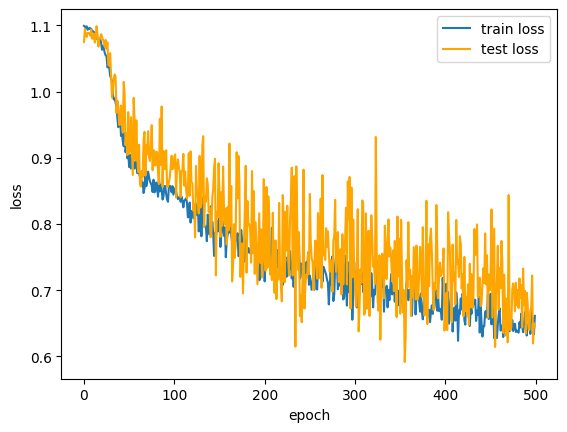

In [39]:
# Training and evaluating with L1 regularization
print("Training with L2 Regularization:")
model = NeuralNetwork(input_size, output_size)
model = model.to(device)                                  # förbered modellen för GPU (om tillgänglig)


optimizer = SGD(model.parameters(), lr = learning_rate)
criterion = torch.nn.CrossEntropyLoss()               # OBS, CrossEntropyLoss!

train_dataloader = DataLoader(training_set,                 
                              batch_size = batch_size,       
                              shuffle=True)


l2_losses = train_model(model, criterion, optimizer, train_dataloader, regularization_type='L2', lambda_reg=0.01)
#evaluate_model(model, test_loader)
plot_training_loss(l2_losses, 'Training Loss with L2 Regularization')


In [ ]:
# ----------------------------------------------------------------------------------------------------------------
#    initera modell, loss_function, optimizer & dataloader


model = NeuralNetwork(input_size, output_size)
model = model.to(device)                                  # förbered modellen för GPU (om tillgänglig)


optimizer = SGD(model.parameters(), lr = learning_rate)
loss_function = torch.nn.CrossEntropyLoss()               # OBS, CrossEntropyLoss!

train_dataloader = DataLoader(training_set,                 
                              batch_size = batch_size,       
                              shuffle=True)


# ----------------------------------------------------------------------------------------------------------------
#    träna



batch_train_losses = []

epoch_train_losses = []
epoch_evaluation_losses = []
epoch_evaluation_accuracies = []

for epoch in range(epochs):
    
    model.train()

    running_loss = 0
    
    for batch in train_dataloader:
        
        y_true = batch[1]
        input_features = batch[0]
        
        y_pred=model(input_features)
        loss=loss_function(y_pred, y_true)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        l1_norm = sum(p.abs().sum() for p i model.parameters())
        loss += lambda_reg * l1_norm
        
        batch_loss = loss.item()
        batch_train_losses.append(batch_loss)
    
    epoch_average_loss = np.average(batch_train_losses[-len(train_dataloader):])
    epoch_train_losses.append(epoch_average_loss)

# ----------------------------------------------------------------------------------------------------------------
#   evalueringssektion 

    #model.eval()
    
    y_true = y_test
    input_features = x_test
    
    y_pred = model(input_features)
    loss = loss_function(y_pred, y_true)
    
    evaluation_loss = loss.item()
    epoch_evaluation_losses.append(evaluation_loss)

# ----------------------------------------------------------------------------------------------------------------
#   evalueringssektion del 2 - samla in accuracy på test set


    _, predicted_class = torch.max(y_pred, dim=1)
    accuracy = (predicted_class == y_true).float().mean().item()
    epoch_evaluation_accuracies.append(accuracy)

# ----------------------------------------------------------------------------------------------------------------
#   plotta resultat 

plt.plot(epoch_train_losses, label = 'train loss')
plt.plot(epoch_evaluation_losses, label = 'test loss', color='orange')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()

plt.show()

plt.plot(epoch_evaluation_accuracies, label = 'test accuracy', color='orange')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.legend()

plt.show()

In [12]:
dropout_layer = nn.Dropout(p=0.2, inplace=False)
input = torch.randn(1,10)
output = dropout_layer(input)



print(f"dropout_layer: {dropout_layer}")
print(f"input: {input}")
print(f"output: {output}")


dropout_layer: Dropout(p=0.2, inplace=False)
input: tensor([[ 0.8621,  1.8074, -0.6403,  0.3571,  0.3364,  0.4373, -0.4146,  0.7201,
         -1.0801,  1.8029]])
output: tensor([[ 1.0776,  2.2592, -0.8004,  0.4464,  0.4205,  0.5466, -0.5183,  0.0000,
         -1.3501,  0.0000]])


In [11]:
output

tensor([[-0.1937,  1.3402,  2.0079, -0.2070,  0.2401,  1.7019,  1.0545,  0.0000,
         -2.3897,  2.4689]])